# modeles lineaires simple

## sklearn

In [39]:
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDRegressor
from sklearn.datasets import make_regression

In [2]:
np.random.seed(0)
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

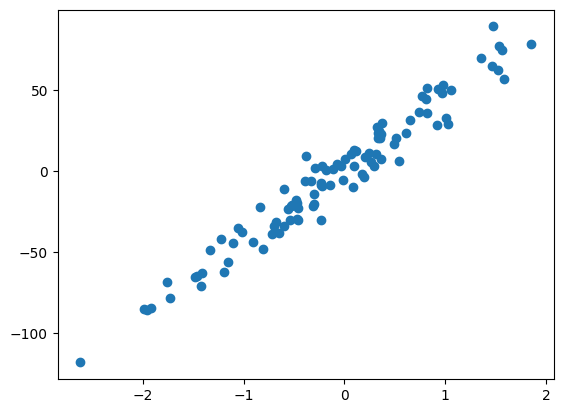

In [3]:
plt.scatter(X,y)

In [5]:
model = SGDRegressor()
model.fit(X, y)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [11]:
model.score(X, y)

0.953823615423576

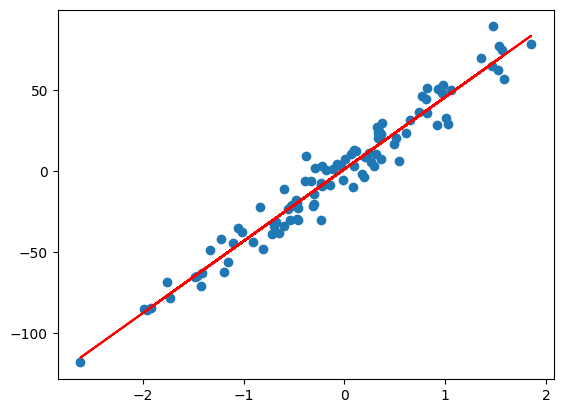

In [7]:
plt.scatter(X,y)
plt.plot(X, model.predict(X), c="r")

/home/fallou/mlpro/module_3/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


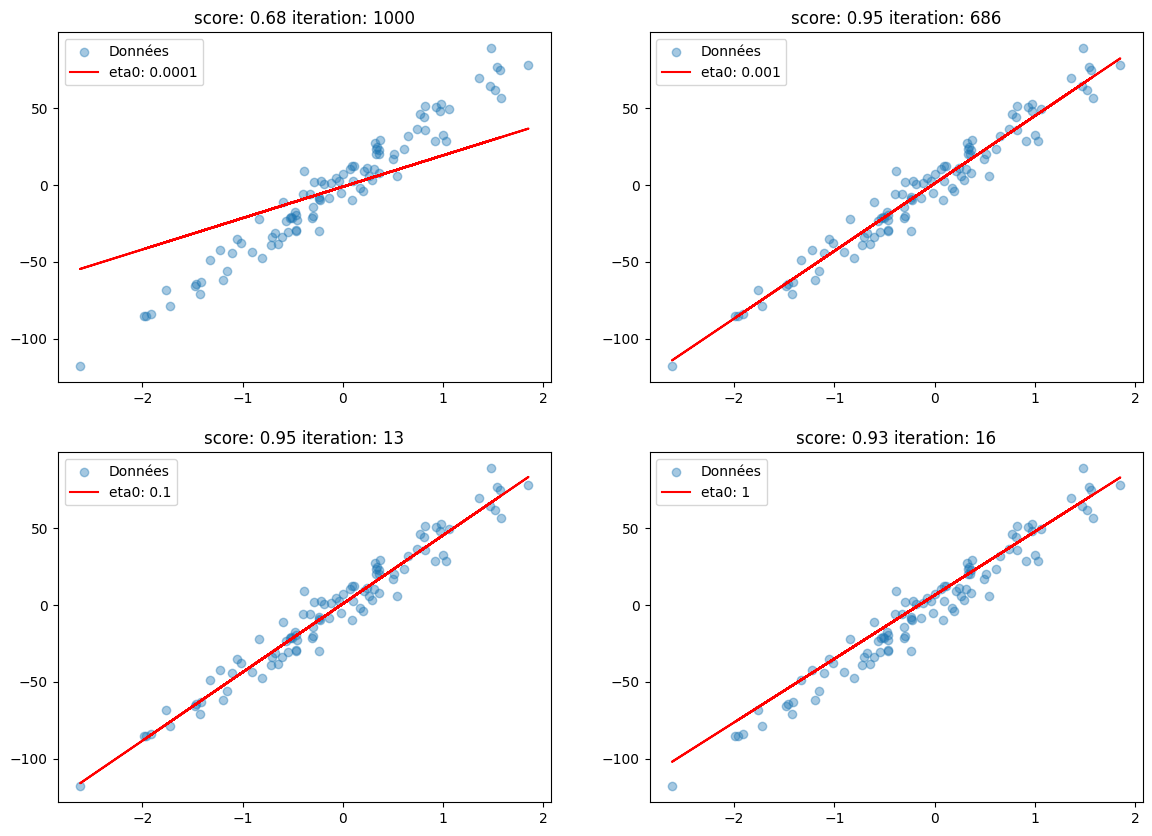

In [31]:
eta_values = [0.0001, 0.001, 0.1, 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

history_loss = []

for eta, ax in zip(eta_values, axes.flatten()):
    model = SGDRegressor(eta0=eta)
    model.fit(X, y)
    s = model.score(X, y)
    y_pred = model.predict(X)
    history_loss.append(np.mean(np.sqrt((y_pred-y)**2)))
    ax.scatter(X,y, alpha=0.4, label="Données")
    ax.plot(X, y_pred, c="r", label=f'eta0: {eta}')
    ax.set_title(f"score: {round(s, 2)} iteration: {model.n_iter_}")
    ax.legend()

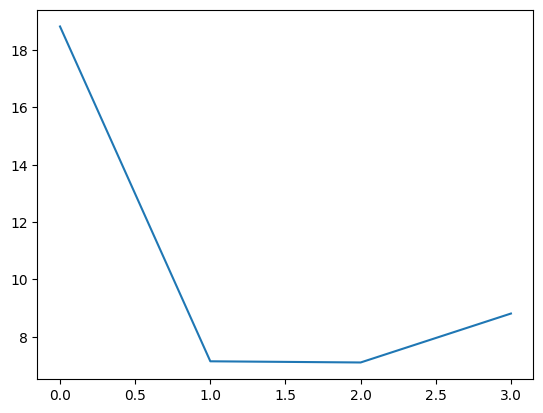

In [32]:
plt.plot(np.arange(4), history_loss)

## from scrach

In [137]:
def linear_regression(x, theta):
    return x.dot(theta)

In [ ]:
def cost_fonction(x, y, theta):
    return np.mean(
        (linear_regression(x, theta) - y)**2
    )

In [138]:
def gradient_descent(x, y, theta):
    return np.mean(
        x.T.dot((linear_regression(x, theta) - y))
    ) 

In [123]:
theta = np.zeros(2)
theta

array([0., 0.])

In [141]:
ones = np.expand_dims(np.ones(X.shape[0]), axis=1)
print(ones.shape)
x = np.hstack((X, ones))
print("x:", x.shape)
y = y.reshape(100, 1)
print("y:", y.shape)

(100, 1)
x: (100, 2)
y: (100, 1)


In [142]:
model = linear_regression(x, theta)

In [143]:
cost_fonction(x, y, theta)

np.float64(27.853436238715723)

In [144]:
gradient_descent(x, y, theta)

np.float64(-1.1791707947850228e-08)

[1.99948533 2.20597133]
[3.56957609 3.77606209]
[5.07662057 5.28310656]
[6.52315034 6.72963634]
[7.91159535 8.11808135]
[9.24428798 9.45077398]
[10.52346693 10.72995293]
[11.75128102 11.95776702]
[12.92979279 13.13627879]
[14.06098194 14.26746794]
[15.14674869 15.35323469]
[16.18891697 16.39540297]
[17.18923745 17.39572345]
[18.1493905 18.3558765]
[19.07098904 19.27747504]
[19.9555812 20.1620672]
[20.80465295 21.01113895]
[21.61963061 21.82611661]
[22.40188321 22.60836921]
[23.1527248 23.3592108]
[23.87341668 24.07990268]
[24.56516951 24.77165551]
[25.2291453 25.4356313]
[25.86645945 26.07294545]
[26.47818253 26.68466853]
[27.06534215 27.27182815]
[27.62892463 27.83541063]
[28.16987671 28.37636271]
[28.6891071 28.8955931]
[29.18748802 29.39397402]
[29.66585669 29.87234269]
[30.12501667 30.33150267]
[30.56573929 30.77222529]
[30.98876489 31.19525089]
[31.39480408 31.60129008]
[31.78453895 31.99102495]
[32.1586242 32.3651102]
[32.51768821 32.72417421]
[32.86233418 33.06882017]
[33.193141

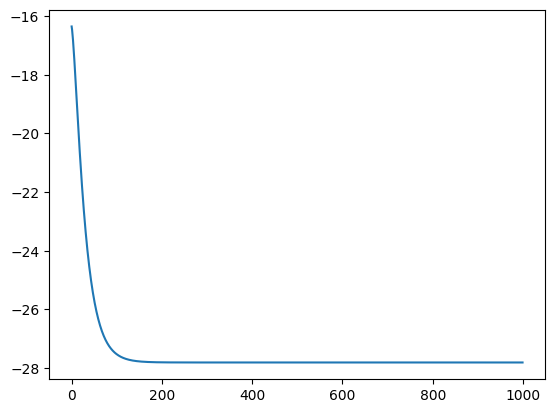

In [170]:
theta = np.random.random(2)
cost_history = []
learning_rate = 0.001
n_iteration = np.arange(1000)
for i in n_iteration:
    #y_pred = linear_regression(x, theta)
    
    gradients = gradient_descent(x, y, theta)
    theta = theta - (learning_rate * gradients)
    print(theta)
    cost_history.append(-cost_fonction(x, y, theta))

plt.plot(n_iteration, cost_history)

In [166]:
theta

array([41.84467753, 41.38442223])

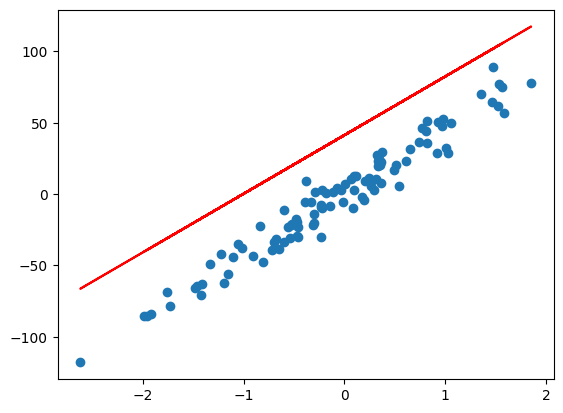

In [171]:
plt.scatter(x[:,0], y)
plt.plot(x[:,0], linear_regression(x, theta), c="r")

# modeles polynomiales

In [172]:
from sklearn.datasets import make_moons
from sklearn.linear_model import SGDClassifier

In [192]:
x, y = make_moons(n_samples=100, noise=0.2, random_state=42)

In [176]:
y.shape

(100,)

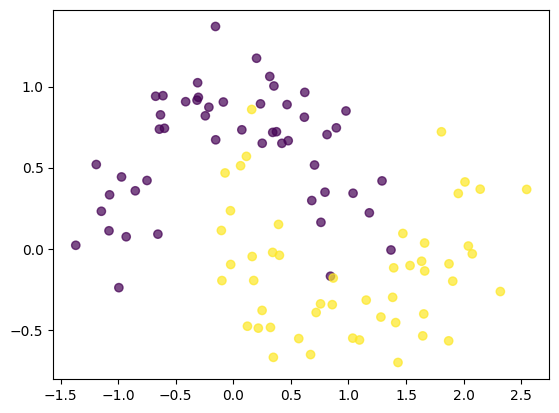

In [198]:
plt.scatter(x[:,0], x[:,1], c=y, alpha=0.7)

In [231]:
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer

In [232]:
column_transformer = ColumnTransformer(transformers=[ 
     ("polynom", PolynomialFeatures()),
    ("std", StandardScaler())
])

In [233]:
model = Pipeline(steps=[ 
     ("column_transformer", column_transformer),
    ("SGD", SGDClassifier())
])

In [240]:
sgd = SGDClassifier()

In [241]:
sgd.fit(x, y)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [242]:
sgd.score(x, y)

0.82